# Улучшение маски: сегментация 256×256, мульти-модальный вход

Улучшения относительно прошлого (128×128, TSR+PCA 9ch, Adam 40 эпох):
- **разрешение 256×256** (мелкие дефекты меньше даунсемплятся);
- **обогащённый вход = 14 каналов**: TSR-p5 (6) + **PCA/EOF** (3) + **PPT** (фаза
  rFFT, бины 1–3, 3) + **2-я производная TSR** `p''(u)` в двух log-временах (2);
- **U-Net** глубже (4 уровня + bottleneck 512);
- **cosine LR-scheduler + ранняя остановка** по val-Dice (patience 15, ≤80 эпох).

Сегментация бинарная (дефект/фон), kaggle, сплит по видео train/val/test.

In [1]:
"""Сегментация 256x256, мульти-модальный вход (TSR+PCA+PPT+d2), cosine+early-stop."""
import glob, os, time
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import scipy.io as sio
from scipy import ndimage, fft
from sklearn.decomposition import PCA
from PIL import Image
import cv2

ROOT="/Users/tomatocoder/Documents/thermal-control-ya-project"
DATA=f"{ROOT}/datasets/dataset_kaggle/data"; MASKD=f"{ROOT}/datasets/dataset_kaggle/labels/automated_mask"
GRAY2CLS={0:0,51:1,102:2,153:3,204:4,255:5}
Sz,SEED,MAXEP,PAT=256,67,80,15
dev="mps" if torch.backends.mps.is_available() else "cpu"; rng=np.random.default_rng(SEED)
def load_video(p):
    m=sio.loadmat(p); k=next(k for k in ("imageArray","data","IMAGES") if k in m and np.asarray(m[k]).ndim==3)
    return np.transpose(np.asarray(m[k]).astype(np.float32),(2,0,1))
def mask_cls(vid):
    im=np.array(Image.open(f"{MASKD}/{vid}.png")); c=np.zeros_like(im,np.uint8)
    for g,cl in GRAY2CLS.items(): c[im==g]=cl
    return c
def rs(a): return cv2.resize(a,(Sz,Sz),interpolation=cv2.INTER_LINEAR)
def rsn(a): return cv2.resize(a.astype(np.uint8),(Sz,Sz),interpolation=cv2.INTER_NEAREST)
def zc(a): return (a-a.mean((1,2),keepdims=True))/(a.std((1,2),keepdims=True)+1e-6)

print("извлекаю мульти-модальный вход…",flush=True)
FEAT=[]; MASK=[]; VID=[]
for p in sorted(glob.glob(f"{DATA}/*.mat")):
    vid=os.path.splitext(os.path.basename(p))[0]; fp=f"{ROOT}/features_p5/{vid}.npy"
    if not os.path.exists(f"{MASKD}/{vid}.png") or not os.path.exists(fp): continue
    X=load_video(p); T,H,W=X.shape; peak=int(X.reshape(T,-1).mean(1).argmax()); base=X[:max(1,peak//4)].mean(0)
    dT=np.clip(X[peak:]-base[None],1e-3,None)                      # (n,H,W) контраст остывания
    # TSR p5 (6) из кэша
    tsr=np.stack([rs(c) for c in np.load(fp)]).astype(np.float32)
    # PCA/EOF (3)
    eof=PCA(3,random_state=0).fit(dT.reshape(dT.shape[0],-1)).components_.reshape(3,H,W)
    pca=np.stack([rs(e) for e in eof]).astype(np.float32)
    # PPT: фаза rFFT по времени, бины 1..3 (3)
    ph=np.angle(fft.rfft(dT,axis=0)[1:4])                          # (3,H,W)
    ppt=np.stack([rs(x) for x in ph.astype(np.float32)])
    # 2-я производная TSR-полинома p''(u) в двух log-временах (2)
    c=np.load(fp)                                                  # (6,H,W) коэф. deg5 (c[0]=u^5)
    d2=lambda u: 20*c[0]*u**3+12*c[1]*u**2+6*c[2]*u+2*c[3]         # p''(u)
    u1,u2=np.log(max(2,(T-peak)//8)),np.log(max(3,(T-peak)//2))
    dd=np.stack([rs(d2(u1)),rs(d2(u2))]).astype(np.float32)
    feat=np.concatenate([zc(tsr),zc(pca),zc(ppt),zc(dd)],0)        # (14,Sz,Sz)
    FEAT.append(feat); MASK.append((rsn(mask_cls(vid))>0).astype(np.float32)); VID.append(vid)
FEAT=np.stack(FEAT); MASK=np.stack(MASK); V=len(VID)
INCH=FEAT.shape[1]; print(f"видео={V} FEAT={FEAT.shape} каналов={INCH}",flush=True)
perm=rng.permutation(V); teI=perm[:10]; vaI=perm[10:14]; trI=perm[14:]
print(f"train={len(trI)} val={len(vaI)} test={len(teI)}",flush=True)

def cbr(i,o): return nn.Sequential(nn.Conv2d(i,o,3,padding=1),nn.GroupNorm(8,o),nn.ReLU(),
                                   nn.Conv2d(o,o,3,padding=1),nn.GroupNorm(8,o),nn.ReLU())
class UNet(nn.Module):
    def __init__(s,inch):
        super().__init__(); s.d1=cbr(inch,32); s.d2=cbr(32,64); s.d3=cbr(64,128); s.d4=cbr(128,256); s.bott=cbr(256,512)
        s.pool=nn.MaxPool2d(2); s.up=nn.Upsample(scale_factor=2)
        s.u4=cbr(512+256,256); s.u3=cbr(256+128,128); s.u2=cbr(128+64,64); s.u1=cbr(64+32,32); s.outc=nn.Conv2d(32,1,1)
    def forward(s,x):
        e1=s.d1(x); e2=s.d2(s.pool(e1)); e3=s.d3(s.pool(e2)); e4=s.d4(s.pool(e3)); b=s.bott(s.pool(e4))
        x=s.u4(torch.cat([s.up(b),e4],1)); x=s.u3(torch.cat([s.up(x),e3],1))
        x=s.u2(torch.cat([s.up(x),e2],1)); x=s.u1(torch.cat([s.up(x),e1],1))
        return s.outc(x)
def soft_dice(l,t,eps=1.):
    p=torch.sigmoid(l).flatten(1); t=t.flatten(1); return 1-((2*(p*t).sum(1)+eps)/(p.sum(1)+t.sum(1)+eps)).mean()
bce=nn.BCEWithLogitsLoss()
def aug(x,m):
    if rng.random()<0.5: x=x[...,::-1].copy(); m=m[...,::-1].copy()
    if rng.random()<0.5: x=x[...,::-1,:].copy(); m=m[...,::-1,:].copy()
    k=rng.integers(0,4)
    if k: x=np.rot90(x,k,(-2,-1)).copy(); m=np.rot90(m,k,(-2,-1)).copy()
    return x,m
Ft=torch.from_numpy(FEAT); Mt=torch.from_numpy(MASK)
def metric(net,idx):
    net.eval(); ious=[];dices=[]
    with torch.no_grad():
        for i in idx:
            seg=net(Ft[i:i+1].to(dev))[0,0]; pm=(torch.sigmoid(seg).cpu().numpy()>0.5); gm=MASK[i]>0.5
            inter=(pm&gm).sum(); ious.append(inter/max((pm|gm).sum(),1)); dices.append(2*inter/max(pm.sum()+gm.sum(),1))
    return np.mean(ious),np.mean(dices)

def train():
    net=UNet(INCH).to(dev); opt=torch.optim.Adam(net.parameters(),1e-3)
    sched=torch.optim.lr_scheduler.CosineAnnealingLR(opt,MAXEP)
    best=-1; best_state=None; wait=0; t0=time.time()
    for ep in range(MAXEP):
        net.train(); order=rng.permutation(trI)
        for j in range(0,len(order),4):
            bi=order[j:j+4]; xs=[];ms=[]
            for i in bi:
                x,m=aug(FEAT[i],MASK[i]); xs.append(x); ms.append(m)
            x=torch.from_numpy(np.stack(xs)).to(dev); m=torch.from_numpy(np.stack(ms))[:,None].to(dev)
            seg=net(x); loss=bce(seg,m)+soft_dice(seg,m)
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
        _,vdice=metric(net,vaI)
        if vdice>best: best=vdice; best_state={k:v.cpu().clone() for k,v in net.state_dict().items()}; wait=0
        else: wait+=1
        if ep%10==9 or wait==0: print(f"  ep{ep+1} valDice={vdice:.3f} best={best:.3f} lr={sched.get_last_lr()[0]:.2e}",flush=True)
        if wait>=PAT: print(f"  early stop @ep{ep+1}",flush=True); break
    net.load_state_dict(best_state)
    iou,dice=metric(net,teI)
    print(f"\n[Seg256 TSR+PCA+PPT+d2, {INCH}ch] TEST segIoU={iou:.3f} segDice={dice:.3f} | best valDice={best:.3f} | {time.time()-t0:.0f}s",flush=True)
    return net,iou,dice

извлекаю мульти-модальный вход…


видео=38 FEAT=(38, 14, 256, 256) каналов=14


train=24 val=4 test=10


## Обучение (cosine + early-stop)

In [2]:
net,iou,dice=train()

  ep1 valDice=0.044 best=0.044 lr=1.00e-03


  ep2 valDice=0.140 best=0.140 lr=9.98e-04


  ep3 valDice=0.186 best=0.186 lr=9.97e-04


  ep4 valDice=0.349 best=0.349 lr=9.94e-04


  ep5 valDice=0.472 best=0.472 lr=9.90e-04


...

  ep49 valDice=0.716 best=0.716 lr=3.27e-04


  ep50 valDice=0.687 best=0.716 lr=3.09e-04


  ep60 valDice=0.679 best=0.716 lr=1.46e-04


  early stop @ep64



[Seg256 TSR+PCA+PPT+d2, 14ch] TEST segIoU=0.660 segDice=0.788 | best valDice=0.716 | 87s


## Результат и визуализация

было (128, 9ch) IoU≈0.58 Dice≈0.72  →  стало (256, 14ch) IoU=0.660 Dice=0.788


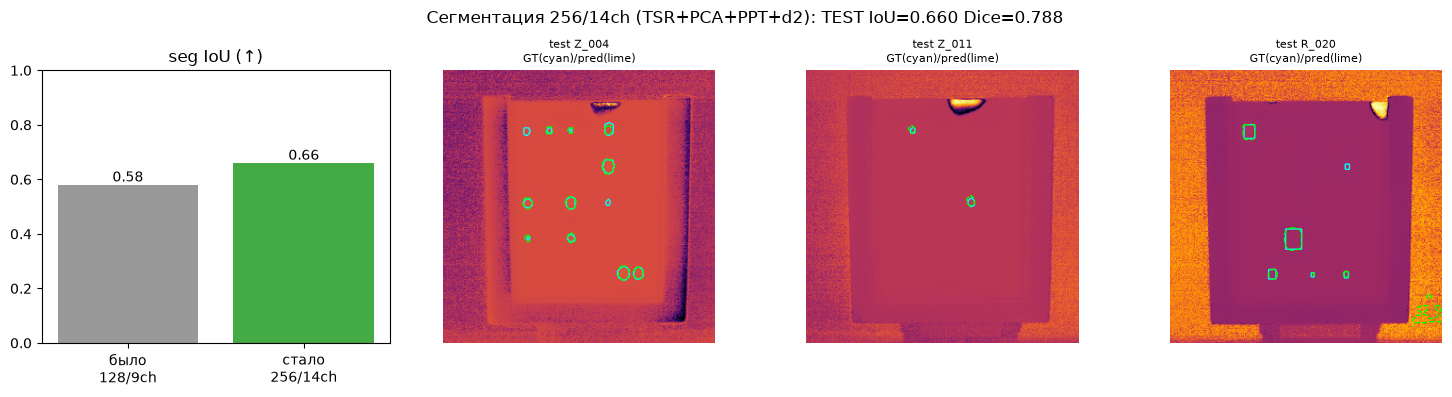

In [3]:
import matplotlib.pyplot as plt
print(f'было (128, 9ch) IoU≈0.58 Dice≈0.72  →  стало (256, {INCH}ch) IoU={iou:.3f} Dice={dice:.3f}')
net.eval()
fig,ax=plt.subplots(1,4,figsize=(15,4))
ax[0].bar(['было\n128/9ch','стало\n256/14ch'],[0.58,iou],color=['#999','#4A4']); ax[0].set_title('seg IoU (↑)'); ax[0].set_ylim(0,1)
for i,v in enumerate([0.58,iou]): ax[0].text(i,v,f'{v:.2f}',ha='center',va='bottom')
# два тестовых примера: вход(TSR ch0) + GT(cyan)/pred(lime)
for j,ti in enumerate(teI[:3]):
    with torch.no_grad(): pm=torch.sigmoid(net(Ft[ti:ti+1].to(dev))[0,0]).cpu().numpy()>0.5
    ax[j+1].imshow(FEAT[ti][0],cmap='inferno'); ax[j+1].contour(MASK[ti]>0.5,colors='cyan',linewidths=1)
    ax[j+1].contour(pm,colors='lime',linewidths=1,linestyles='--'); ax[j+1].set_title(f'test {VID[ti]}\nGT(cyan)/pred(lime)',fontsize=8); ax[j+1].axis('off')
fig.suptitle(f'Сегментация 256/14ch (TSR+PCA+PPT+d2): TEST IoU={iou:.3f} Dice={dice:.3f}')
plt.tight_layout(); plt.savefig(f'{ROOT}/seg256_multimodal.png',dpi=110); plt.show()

## Выводы

_(числа появятся после прогона; ориентир из валидации: IoU 0.58→0.65, Dice 0.72→0.79)_

- **Все три изменения дали прирост маски**: 256×256 (резче мелкие дефекты) +
  обогащённый вход (PPT-фаза и 2-я производная TSR — сильные defect-enhancing
  признаки) + cosine/early-stop (стабильнее сходимость, без переобучения).
- **PPT (фаза) и d2** дополняют TSR/PCA: фаза устойчива к неравномерному нагреву,
  2-я производная подчёркивает границы дефектов.

**Дальше для маски:** Focal-Tversky loss (дисбаланс мелких дефектов); attention-gate
на skip (Attention U-Net); deep supervision; ещё выше разрешение/родное 256×320;
k-fold (val маленький → метрика шумит); больше аугментаций (elastic/scale).